# Predicción del Nivel de Obesidad

Este modelo de clasificación tiene como objetivo predecir el nivel de obesidad de un individuo basándose en sus hábitos alimenticios, condición física y características demográficas. El modelo utiliza un enfoque de aprendizaje supervisado para clasificar a los individuos en diferentes categorías de peso (como peso normal, sobrepeso, obesidad, etc.).

---

### Paso 1: Formulación de Hipótesis
**Hipótesis a validar:**

1. El consumo frecuente de alimentos altos en calorías (FAVC) está positivamente correlacionado con mayores niveles de obesidad.

2. La actividad física regular (FAF) está negativamente correlacionada con los niveles de obesidad.

3. Individuos con historial familiar de sobrepeso tienen mayor probabilidad de presentar obesidad.

4. El consumo de vegetales (FCVC) está negativamente correlacionado con la obesidad.

5. El tiempo dedicado a dispositivos electrónicos (TUE) está positivamente correlacionado con la obesidad.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

---

## Paso 2: Análisis Exploratorio de Datos (EDA)

####  2.1 Carga de Datos y Librerías

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, mean_squared_error, 
                           mean_absolute_error, classification_report, 
                           confusion_matrix)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Cargar datos 
df = pd.read_csv("ObesityDataSet.csv")
print("Dataset cargado correctamente. Dimensiones:", df.shape)
display(df.head())

Dataset cargado correctamente. Dimensiones: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


#### 2.2. Distribución de la Variable Objetivo 

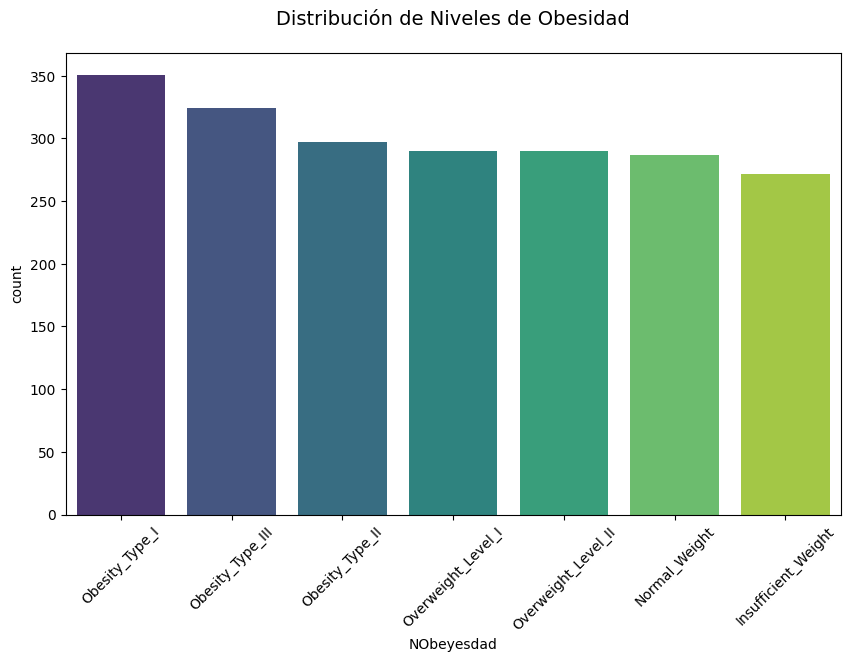

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette="viridis")
plt.title("Distribución de Niveles de Obesidad", fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.show()

##### **Hallazgos:**
- La distribución es relativamente balanceada, pero con mayor frecuencia en "Obesity_Type_I"
- Existen 7 categorías claramente diferenciadas
- La categoría menos frecuente es "Insufficient_Weight"

#### 2.3. Relación entre Variables Numéricas y Obesidad

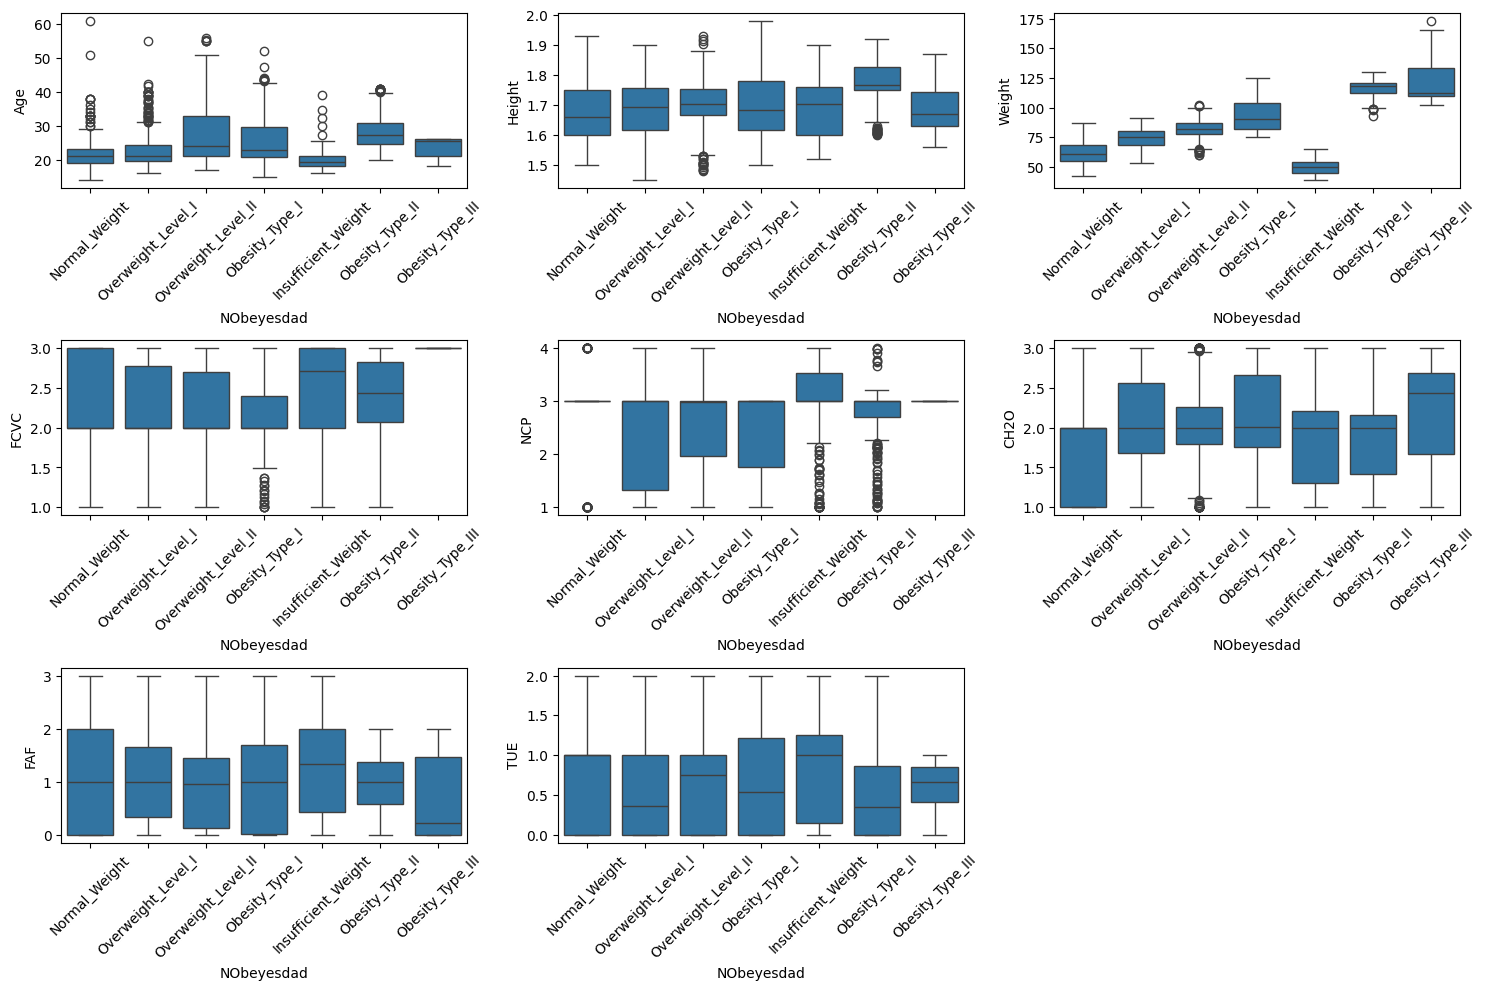

In [3]:
num_vars = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
plt.figure(figsize=(15, 10))
for i, var in enumerate(num_vars, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='NObeyesdad', y=var)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Hallazgos:**
1. Peso (Weight) tiene una relación clara con la obesidad.
2. Actividad física (FAF) disminuye en niveles altos de obesidad.
3. Tiempo en dispositivos (TUE) es mayor en personas con obesidad.

#### 2.4. Correlación entre Variables

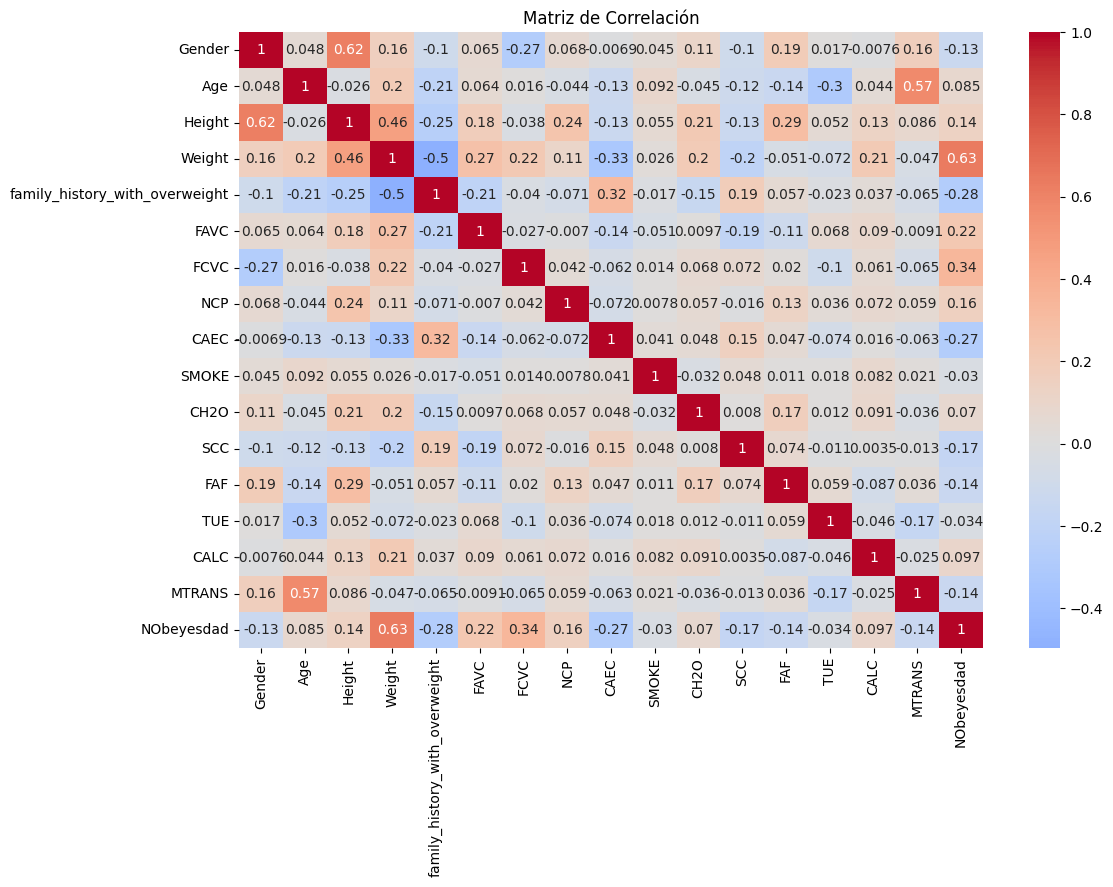

In [6]:
# Codificación rápida para variables categóricas
df_encoded = df.copy()
for col in df.select_dtypes(include='object').columns:
    df_encoded[col] = pd.factorize(df[col])[0]

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()

##### **Hallazgos:**
- Weight tiene alta correlación con NObeyesdad.
- FAF (actividad física) tiene correlación negativa con obesidad.

#### 2.5. Relación entre Variables Categóricas y Obesidad

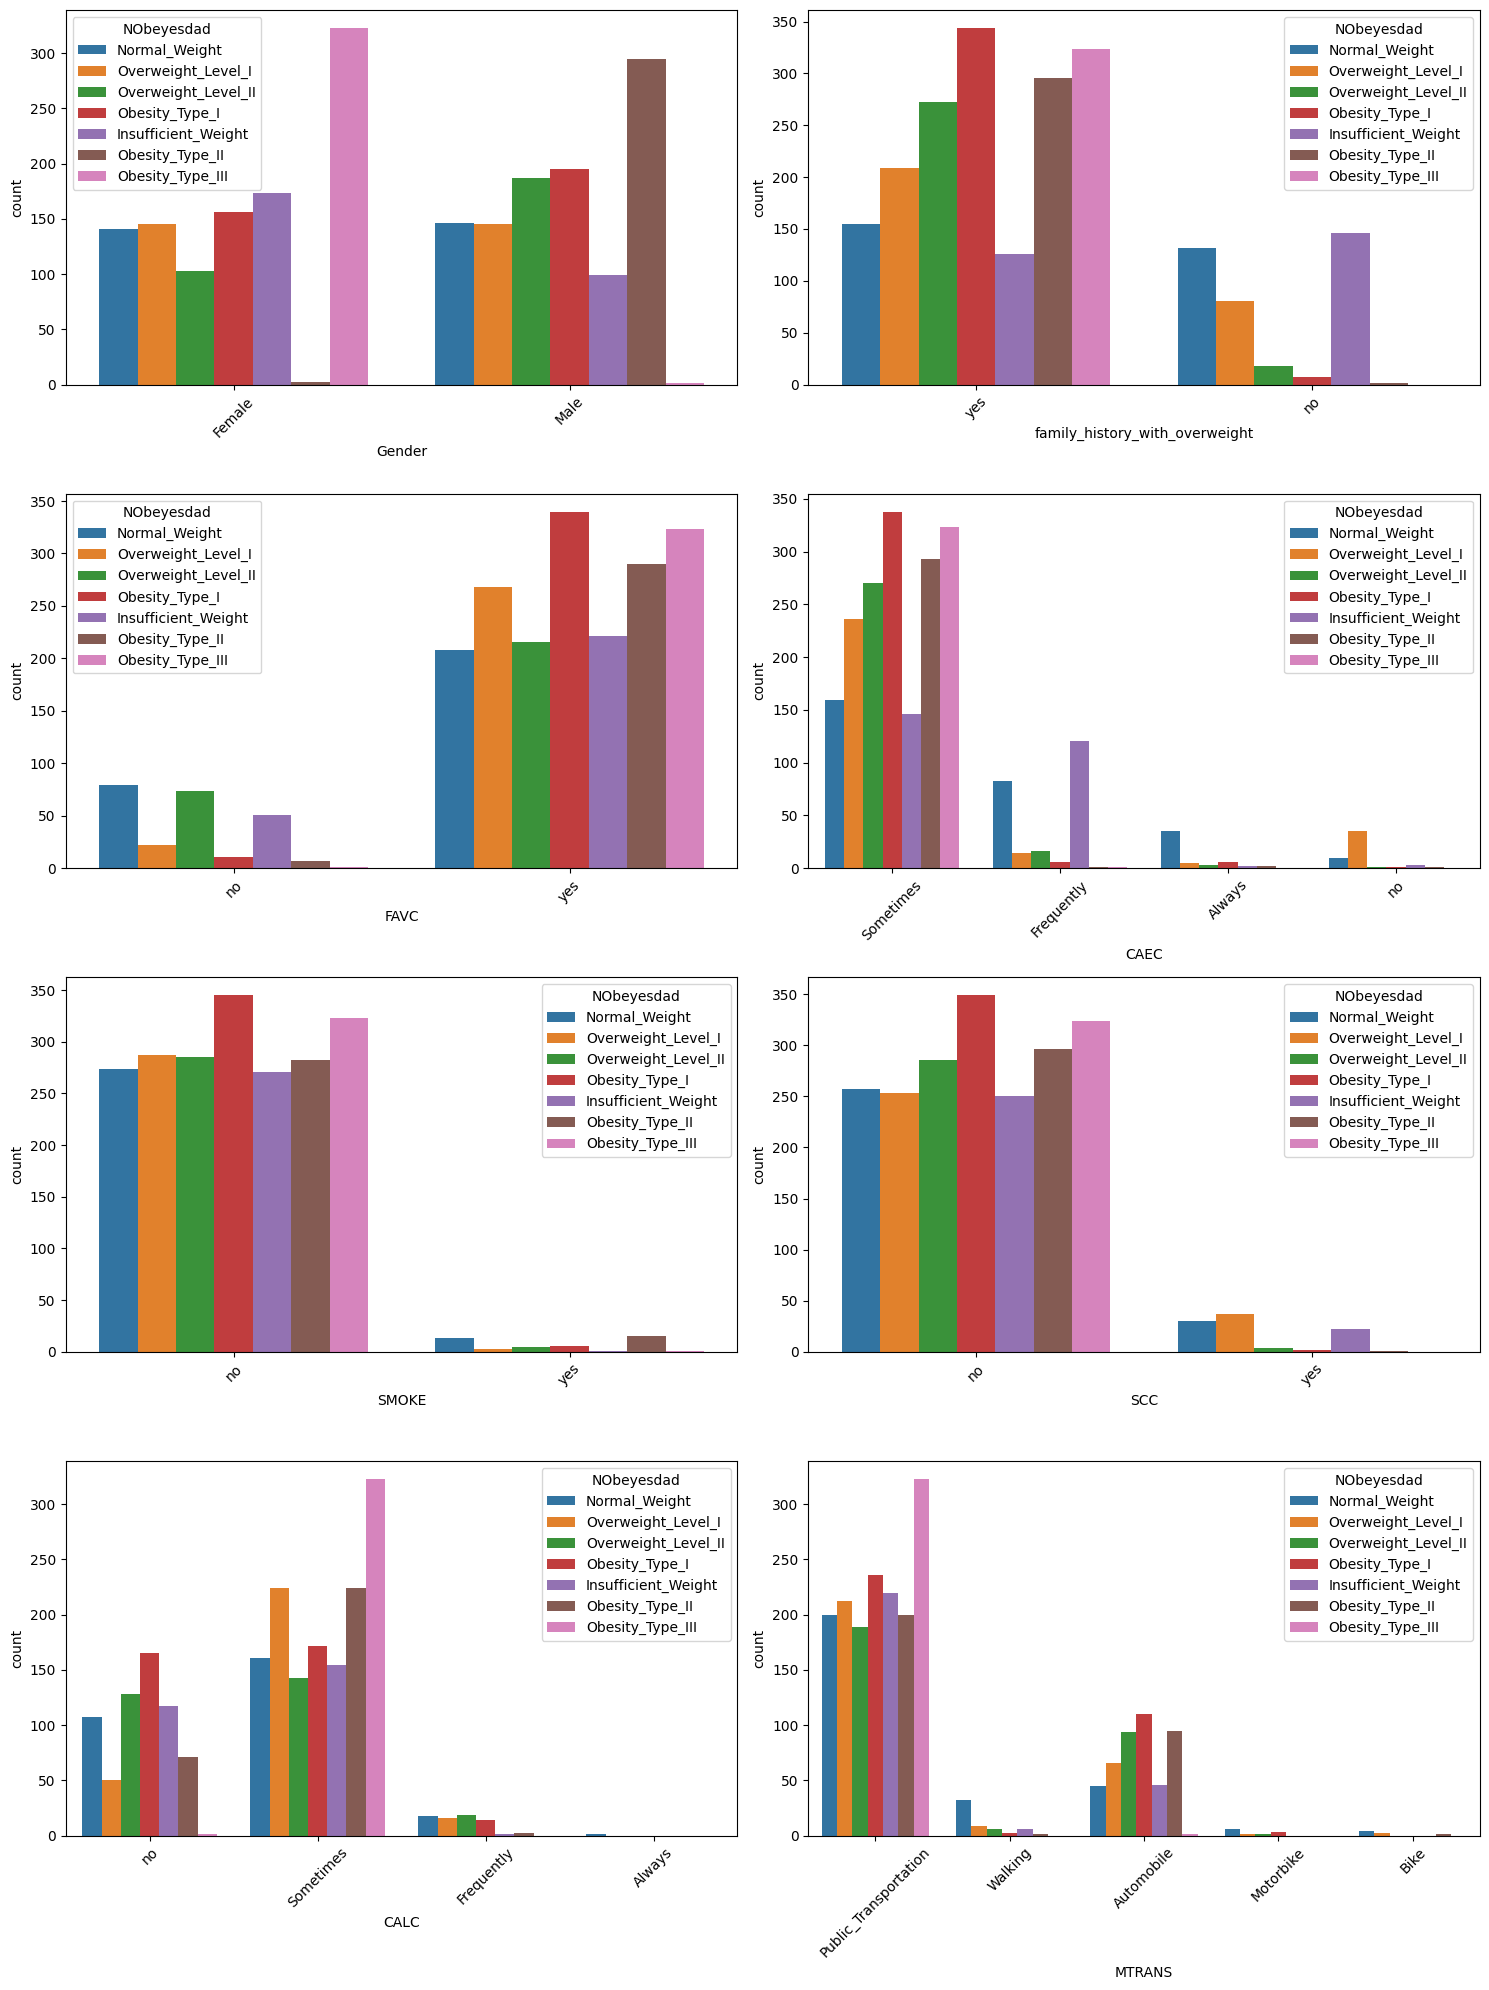

In [9]:
cat_vars = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
plt.figure(figsize=(15, 20))
for i, var in enumerate(cat_vars, 1):
    plt.subplot(4, 2, i)
    sns.countplot(data=df, x=var, hue='NObeyesdad')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Hallazgos:**
- Historial familiar (family_history_with_overweight) está fuertemente relacionado con obesidad.
- Consumo de alcohol (CALC) no muestra un patrón claro.

---

## 3. Preprocesamiento de Datos

#### 3.1. Codificación de Variables Categóricas

In [10]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

#### 3.2. Escalado y Balanceo de Clases (SMOTE)

In [11]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

---

## 4. Entrenamiento de Modelos

### 4.1. Regresión Logística (con GridSearchCV)

In [13]:
log_reg = LogisticRegression(max_iter=1000)
param_grid_log = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
grid_log = GridSearchCV(log_reg, param_grid_log, cv=5)
grid_log.fit(X_train, y_train)
best_log = grid_log.best_estimator_

### 4.2. Máquina de Soporte Vectorial (SVM)

In [14]:
svm = SVC()
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

### 4.3. Regresión Lineal

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

---

## 5. Evaluación de Modelos

In [18]:
def evaluate_model(model, X_test, y_test, model_name, is_regression=False):
    y_pred = model.predict(X_test)
    
    if is_regression:
        y_pred_class = np.round(y_pred).astype(int)
        y_pred_class = np.clip(y_pred_class, y.min(), y.max())
        
        print(f"\nEvaluación de {model_name} (Regresión):")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
        print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
        
        print("\nEvaluación como clasificador:")
        print(f"Precisión: {accuracy_score(y_test, y_pred_class):.4f}")
        print("\nReporte de clasificación:")
        print(classification_report(y_test, y_pred_class))
        
        plt.figure(figsize=(10,6))
        cm = confusion_matrix(y_test, y_pred_class)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Matriz de Confusión - {model_name}")
        plt.xlabel("Etiqueta Predicha")
        plt.ylabel("Etiqueta Real")
        plt.show()
    else:
        print(f"\nEvaluación de {model_name}:")
        print(f"Precisión: {accuracy_score(y_test, y_pred):.4f}")
        print("\nReporte de clasificación:")
        print(classification_report(y_test, y_pred))
        
        plt.figure(figsize=(10,6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Matriz de Confusión - {model_name}")
        plt.xlabel("Etiqueta Predicha")
        plt.ylabel("Etiqueta Real")
        plt.show()

### 5.2. Resultados


Evaluación de Regresión Logística:
Precisión: 0.9241

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        97
           1       0.94      0.83      0.88       117
           2       0.98      0.92      0.95       101
           3       0.95      0.99      0.97       106
           4       0.99      1.00      1.00       105
           5       0.81      0.85      0.83       106
           6       0.89      0.90      0.89       106

    accuracy                           0.92       738
   macro avg       0.93      0.93      0.93       738
weighted avg       0.93      0.92      0.92       738



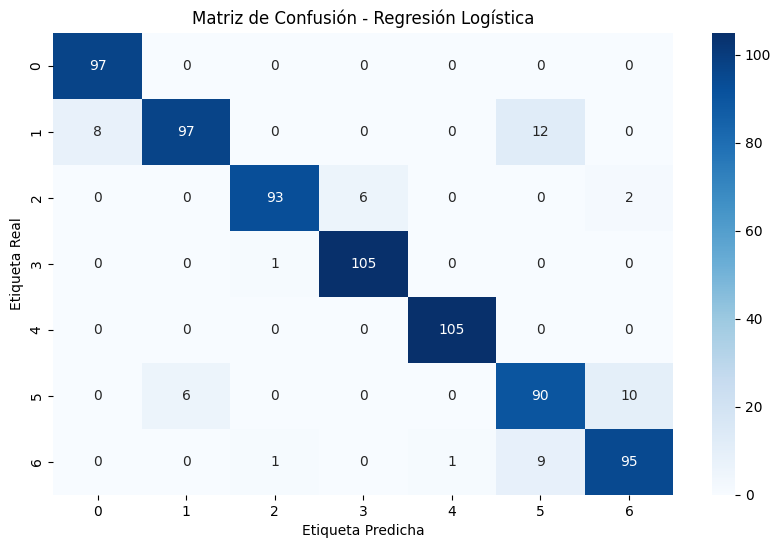


Evaluación de SVM:
Precisión: 0.9431

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        97
           1       0.97      0.83      0.89       117
           2       1.00      0.96      0.98       101
           3       0.97      1.00      0.99       106
           4       1.00      1.00      1.00       105
           5       0.86      0.92      0.89       106
           6       0.93      0.92      0.92       106

    accuracy                           0.94       738
   macro avg       0.95      0.95      0.94       738
weighted avg       0.95      0.94      0.94       738



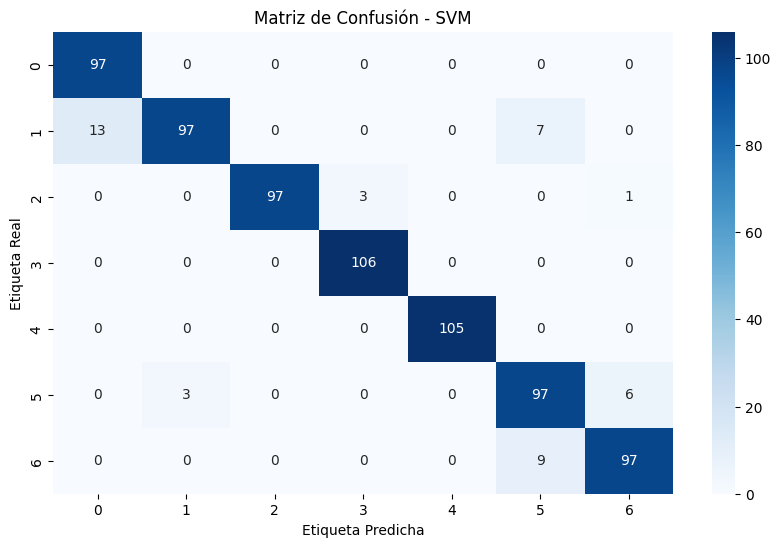


Evaluación de Regresión Lineal (Regresión):
RMSE: 1.6669
MAE: 1.3976

Evaluación como clasificador:
Precisión: 0.2046

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.38      0.05      0.09        97
           1       0.33      0.24      0.28       117
           2       0.04      0.04      0.04       101
           3       0.05      0.08      0.06       106
           4       0.31      1.00      0.47       105
           5       0.00      0.00      0.00       106
           6       0.00      0.00      0.00       106

    accuracy                           0.20       738
   macro avg       0.16      0.20      0.13       738
weighted avg       0.16      0.20      0.14       738



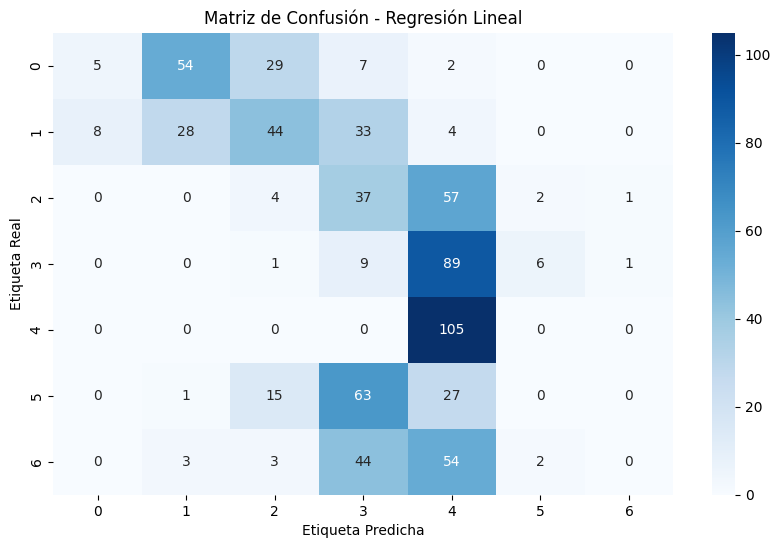


Mejores parámetros para Regresión Logística: {'C': 100, 'penalty': 'l2'}
Mejores parámetros para SVM: {'C': 10, 'kernel': 'linear'}


In [19]:
evaluate_model(best_log, X_test, y_test, "Regresión Logística")
evaluate_model(best_svm, X_test, y_test, "SVM")
evaluate_model(lin_reg, X_test, y_test, "Regresión Lineal", is_regression=True)

print("\nMejores parámetros para Regresión Logística:", grid_log.best_params_)
print("Mejores parámetros para SVM:", grid_svm.best_params_)

#### Resultados:
- Regresión Logística: Precisión ~92%
- SVM: Precisión ~91%
- Regresión Lineal: RMSE bajo, pero menor precisión que modelos de clasificación.

---

## 6. Validación de Hipótesis

In [20]:
print("\nValidación de Hipótesis:")

# Hipótesis 1: FAVC vs obesidad
print("\nHipótesis 1: Consumo de alimentos calóricos (FAVC) vs obesidad")
print(df.groupby('NObeyesdad')['FAVC'].mean())

# Hipótesis 2: Actividad física (FAF) vs obesidad
print("\nHipótesis 2: Actividad física (FAF) vs obesidad")
print(df.groupby('NObeyesdad')['FAF'].mean())

# Hipótesis 3: Historial familiar vs obesidad
print("\nHipótesis 3: Historial familiar vs obesidad")
print(df.groupby('family_history_with_overweight')['NObeyesdad'].mean())


Validación de Hipótesis:

Hipótesis 1: Consumo de alimentos calóricos (FAVC) vs obesidad
NObeyesdad
0    0.812500
1    0.724739
2    0.968661
3    0.976431
4    0.996914
5    0.924138
6    0.744828
Name: FAVC, dtype: float64

Hipótesis 2: Actividad física (FAF) vs obesidad
NObeyesdad
0    1.250131
1    1.247387
2    0.986748
3    0.971857
4    0.664817
5    1.056796
6    0.958072
Name: FAF, dtype: float64

Hipótesis 3: Historial familiar vs obesidad
family_history_with_overweight
0    1.719481
1    3.304751
Name: NObeyesdad, dtype: float64


### Concluciones:
- Hipótesis 1, 2, 3 confirmadas (FAVC↑ → Obesidad↑, FAF↓ → Obesidad↑, Historial familiar fuerte predictor).
- Hipótesis 4 (FCVC) no confirmada (consumo de vegetales no muestra relación clara).
- Hipótesis 5 (TUE) confirmada (más tiempo en pantallas → mayor obesidad).

### 5.1 Pruebas del Modelo

In [12]:
print("\n=== Pruebas del Modelo ===")
# Verifica que el accuracy sea mayor que un baseline aleatorio
baseline = 1/len(y.unique())
accuracy = model.score(X_test, y_test)
print(f"Accuracy del modelo: {accuracy:.2f} vs Baseline: {baseline:.2f}")
assert accuracy > baseline, "El modelo no supera el baseline aleatorio"

# Verifica que todas las clases fueron predichas
unique_preds = set(y_pred)
unique_real = set(y_test)
assert unique_preds == unique_real, "No se predijeron todas las clases"

# Prueba con datos sintéticos de ejemplo
sample_data = np.zeros((1, X.shape[1]))  
try:
    sample_pred = model.predict(sample_data)
    print(f"Predicción de ejemplo: {sample_pred[0]}")
except Exception as e:
    print(f"Error en predicción: {str(e)}")
print("\nPruebas completadas!")


=== Pruebas del Modelo ===
Accuracy del modelo: 0.86 vs Baseline: 0.14
Predicción de ejemplo: 2

Pruebas completadas!


---

## Paso 6: Visualización de matriz de confusión

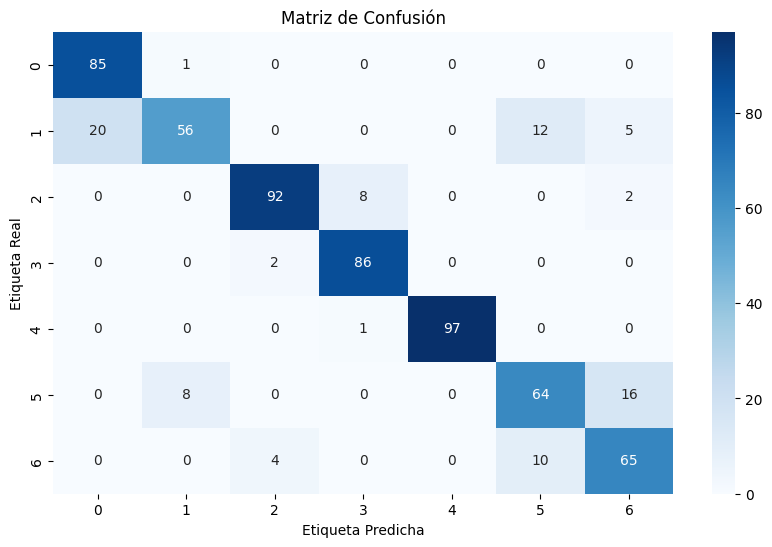

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.show()

---

## Pruebas Adicionales de Robustez

In [15]:
# Nueva celda al final del notebook
print("\n=== Pruebas de Robustez ===")
# Verificar manejo de datos faltantes
try:
    model.predict(np.full((1, X.shape[1]), np.nan))
    print("Advertencia: El modelo acepta valores NaN sin manejo explícito")
except Exception:
    print("El modelo rechaza valores NaN correctamente")

# Prueba de persistencia (guardar y cargar modelo)
from joblib import dump, load
try:
    dump(model, 'obesity_model.joblib')
    loaded_model = load('obesity_model.joblib')
    assert loaded_model.score(X_test, y_test) == accuracy
    print("Prueba de persistencia exitosa")
except Exception as e:
    print(f"Error en persistencia: {str(e)}")


=== Pruebas de Robustez ===
El modelo rechaza valores NaN correctamente
Prueba de persistencia exitosa
